In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn tqdm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [3]:
x = loadmat('data/x')['x'].ravel()
H = loadmat('data/H')['H']
G = loadmat('data/G')['G']
print(f"x shape: {x.shape}, H shape: {H.shape}, G shape: {G.shape}")


x shape: (8100,), H shape: (16200, 8100), G shape: (16200, 8100)


y shape: (16200,)


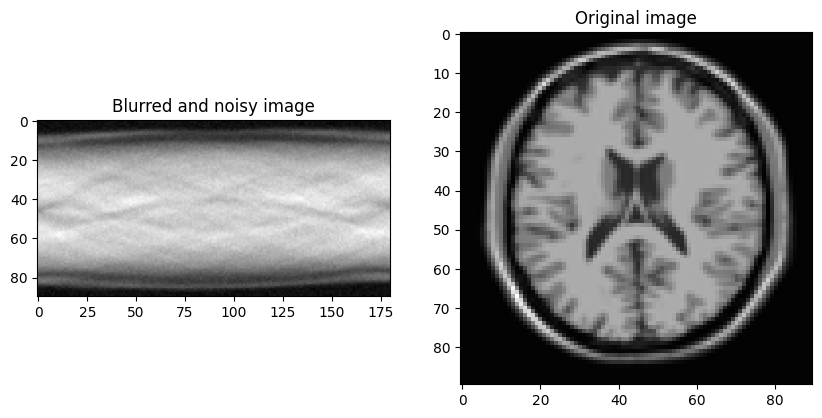

In [4]:
sigma = 1
y = H @ x + sigma * np.random.standard_normal(H.shape[0]) 
print(f"y shape: {y.shape}")
Y = y.reshape((90,180),order='F')
X = x.reshape((90,90),order='F')

plt.figure(figsize=(10,7))
plt.subplot(1,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.subplot(1,2,1)
plt.imshow(Y, cmap='gray')
plt.title("Blurred"" and noisy image")
plt.show()


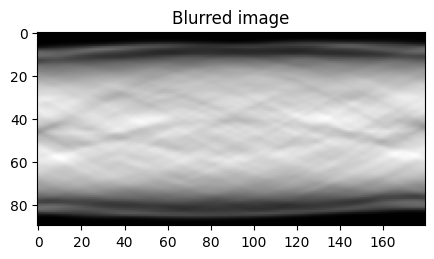

In [5]:
y2 = H @ x  
Y2 = y2.reshape((90,180),order='F')
plt.figure(figsize=(5,3.5))
plt.imshow(Y2, cmap='gray')
plt.title("Blurred image")
plt.show()


### Gradient de f
$$x \in \R^N, G \in \R^{2N \times N}$$
$$f(x) = \frac{1}{2}||Hx - y||^2 + \lambda r(x)$$
$$r(x) = \sum_{n=1}^{2N}{\psi([Gx]^{(n)})} = \mathbb{1}^T\psi(Gx)$$
$$\psi(u) = \sqrt{1+\frac{u^2}{\delta^2}} $$

D'abord :
$$\nabla f(x) =  H^T (Hx-y) + \lambda \nabla r(x)  $$
puis on calcul la dérivée de psi :
$$\psi '(u) = \frac{u}{\delta^2 \sqrt{1+\frac{u^2}{\delta^2}}} = \frac{u}{\delta \sqrt{\delta^2+u^2}} = \frac{1}{\delta \sqrt{\frac{\delta^2}{u^2}+1}} $$
puis on compose :

$$\nabla_{x}r(x) = G^T\psi '(Gx) = G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N}$$
Et enfin : 

$$\nabla f(x) =  H^T (Hx-y) + \lambda G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N} =  H^T (Hx-y) + \lambda G^T[\frac{[Gx]_{(n)}}{\delta^2 \sqrt{\frac{[Gx]_{(n)}^2}{\delta^2}+1}}]_{1<n<2N}  $$

In [6]:
lamb, delta = 0.13,0.02
def f(x):
    return 0.5 * np.linalg.norm(H @ x - y)**2 + lamb * np.sum(np.sqrt(1 +((G @ x)**2 / delta**2)))
def grad_f(x):
    return H.T @ (H @ x - y) + lamb * G.T @ (G @ x / (delta * np.sqrt((delta**2 + (G @ x))**2)))


### Lipschitz constant

Le premier terme du gradient a une constante de lipschitz évidente : $||H||^2$.
Calculons la hésienne de r pour le second terme.
$$\psi'' = \frac{\delta^2 \sqrt{\frac{u^2}{\delta^2}+1} - u^2/\sqrt{\frac{u^2}{\delta^2}+1}}{\delta^4 (\frac{u^2}{\delta^2}+1)} =  \frac{\delta^2 (\frac{u^2}{\delta^2}+1)- u^2}{\delta^4 (\frac{u^2}{\delta^2}+1)^{3/2}} = \frac{1}{\delta^2 (1 +\frac{u^2}{\delta^2})^{3/2}} $$

On a $\nabla r(x) = G^T\psi'(Gx)$ donc $\nabla^2r(x) = G^Tdiag(\psi''(Gx))G $ et comme $\psi'' \leq 1/ \delta^2$ il vient :
$$\nabla^2r(x) \leq ||G||^2 / \delta^2$$

Donc au final la constante de lipschitz est : $$ ||H||^2+ \lambda ||G||^2 / \delta^2$$

In [7]:
from scipy.sparse.linalg import svds
def max_sv(A):
    """Compute the largest singular value of matrix A using sparse SVD."""
    return svds(A,k=1,which='LM',return_singular_vectors=False)[0]

lipschitz_const = max_sv(H)**2 + lamb * max_sv(G)**2/(delta**2)
print(f"Lipschitz constant estimate: {lipschitz_const}")

Lipschitz constant estimate: 18092.773276864802


In [8]:
def gradient_descent(x0,gamma_factor=1, lipschitz_const=lipschitz_const,n_iter=1000,tol=1e-6):
    xn = x0.copy()
    xn1 = xn
    gamma= gamma_factor / lipschitz_const
    for n in range(n_iter):
        grad_xn = grad_f(xn)
        xn1 = xn - gamma * grad_xn
        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            print(f"Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
    return xn

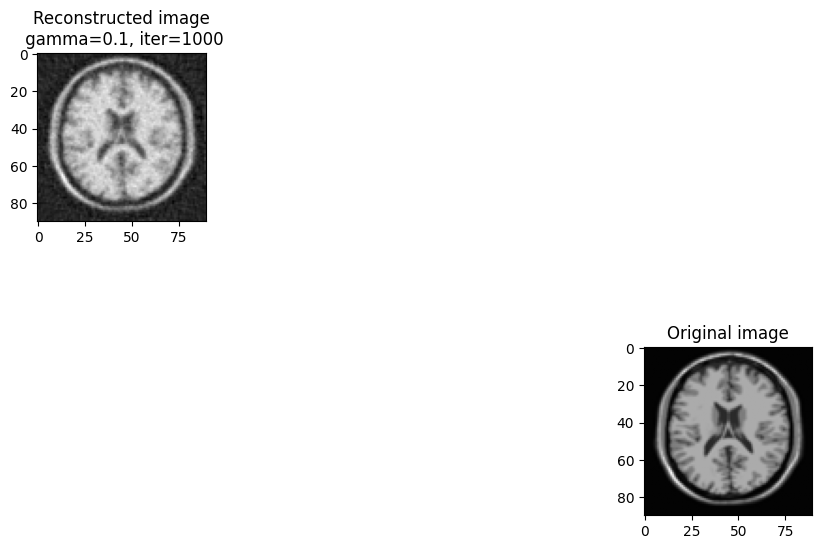

In [11]:
plt.figure(figsize=(10,7))
# grid_para = [(0.1,1000),(0.5,1000),(1,1000),(2,1000),(0.1,500),(0.1,1500),(0.1,2000)]
grid_para =[(0.1,1000)]
for i,(gamma_factor, n_iter) in enumerate(grid_para):
    x0 = np.zeros_like(x)
    x_est = gradient_descent(x0, gamma_factor=gamma_factor,n_iter=n_iter)
    X_est = x_est.reshape((90,90),order='F')
    plt.subplot(2,4,i+1)
    plt.imshow(X_est, cmap='gray')
    plt.title(f"Reconstructed image\n gamma={gamma_factor}, iter={n_iter}")
    
plt.subplot(2,4,8)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.show()

régularisation trop importante

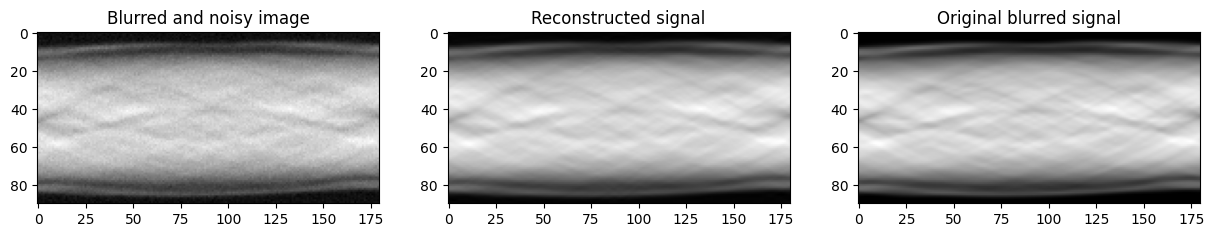

In [14]:
y_mmg = H @ x_est
Y_mmg = y_mmg.reshape((90,180),order='F')
plt.figure(figsize=(15,7))
plt.subplot(1,3,2)
plt.imshow(Y_mmg, cmap='gray')
plt.title("Reconstructed signal")
plt.subplot(1,3,1)
plt.imshow(Y, cmap='gray')
plt.title("Blurred and noisy image")
plt.subplot(1,3,3)
y2 = H @ x
Y2 = y2.reshape((90,180),order='F')
plt.imshow(Y2, cmap='gray')
plt.title("Original blurred signal")
plt.show()


$$\nabla^2 f(x) = H^TH + \lambda G^Tdiag(\psi''(Gx))G$$
Posons $A = H^TH + \frac{\lambda}{\delta^2} G^TG$ alors $A - \nabla^2 f(x)$ est semi-définie positive $\forall x \in \mathbb{R}^N$ car les valeurs propres de $\frac{1}{\delta^2}I_{2N}-diag(\psi''(Gx))$ sont positives et A est strictement positive.
D'après le cours, $\forall z \in \mathbb{R}^N$ la fonction h définie par :
$$\forall x \in \mathbb{R}^N, h(x,z) = f(z) + \langle \nabla f(z), x - z \rangle+ \frac{1}{2}\ || x - z||_A^2$$
est une fonction majorante de $f$ en $z$.
Son gradient est :
$$\nabla_x h(x,z) = \nabla f(z) + (A^T+A)(x-z)$$


In [26]:
from scipy.sparse import diags
from scipy.sparse.linalg import LinearOperator, cg, bicg #resolve Ax = b where A is sparse matrix
from tqdm import trange
### MM algorithm with the hessian of f
def psi_2nd(x):
    return 1/(np.sqrt(1 + (x**2)/(delta**2))**(3/2)*delta**2)
def hess_f(y):
    d = psi_2nd(G @ y)
    A = H.T @ H + lamb *G.T @ diags(d,offsets=0).tocsc() @ G #A symétrique définie positive
    curv_A = LinearOperator(shape=(G.shape[1],G.shape[1]), matvec=lambda v: A @ v)
    return curv_A
### Majoration of the Hessian of f with the second derivative of the regularizer
d = 1/(delta**2) *np.ones(G.shape[0])
A = H.T @ H + lamb *G.T @ diags(d,offsets=0).tocsc() @ G #A symétrique définie positive
### Majoration of the Hessian of f with Lipschitz constant
# d = lipschitz_const *np.ones(G.shape[1])
# A = diags(d,offsets=0).tocsc()

#Linear operator for the curvature matrix
curv_A = LinearOperator(shape=(G.shape[1],G.shape[1]), matvec=lambda v: A @ v)
def mm(x0,theta=1, n_iter=100):
    xn = x0.copy()
    for n in range(n_iter):
        b = grad_f(xn)
        temp, exit_code = cg(curv_A, b, x0=xn, rtol=1e-6, maxiter=1000)
        xn1 = xn -theta * temp
        resid = np.linalg.norm(xn1 - xn)
        if resid < 1e-6:
            xn = xn1
            print(f"MM Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
    return xn

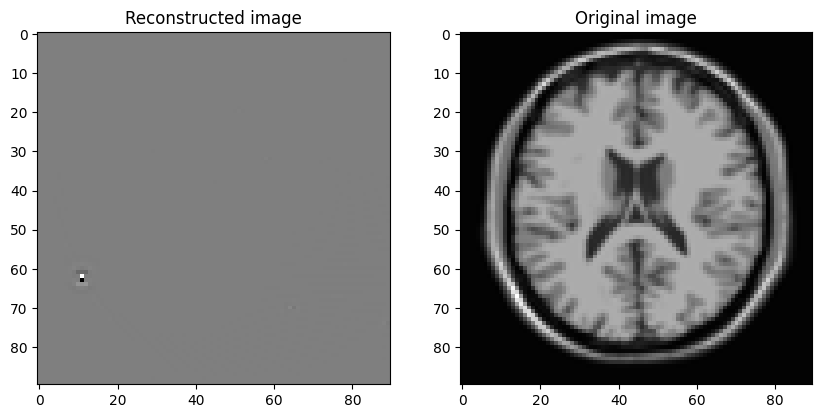

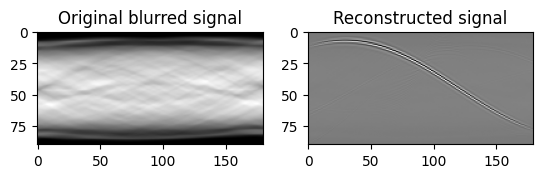

In [27]:
x0 = np.zeros_like(x)
x_mm = mm(x0 ,n_iter=100)
X_mm = x_mm.reshape((90,90),order='F')
plt.figure(figsize=(10,14))
plt.subplot(2,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.subplot(2,2,1)
plt.imshow(X_mm, cmap='gray')
plt.title("Reconstructed image")
plt.show()
y_mm = H @ x_mm  
Y_mm = y_mm.reshape((90,180),order='F')
plt.subplot(2,2,4)
plt.imshow(Y_mm, cmap='gray')
plt.title("Reconstructed signal")
plt.subplot(2,2,3)
plt.imshow(Y2, cmap='gray')
plt.title("Original blurred signal")
plt.show()

### 3.3 Supspace strategy

In [11]:
from scipy.linalg import pinv
def mmmg(x0, n_iter=100):
    xn = x0.copy()
    D = - grad_f(xn)
    temp_h = H @ D
    temp_g = G @ D
    temp = (temp_h.T @ temp_h) + lamb * (temp_g.T @ diags(d,offsets=0).tocsc() @ temp_g)
    u = np.array(- 1/temp * (D.T @ grad_f(xn)))
    xn1 = xn + u*D
    for n in range(n_iter):
        D = np.column_stack((-grad_f(xn1),xn1 - xn))
        xn = xn1
        temp_h = H @ D
        temp_g = G @ D
        u = - pinv((temp_h.T @ temp_h) + lamb * (temp_g.T @ diags(d,offsets=0).tocsc() @ temp_g)) @ (D.T @ grad_f(xn1))
        xn1 = xn + D @ u
        resid = np.linalg.norm(xn1 - xn)
        if resid < 1e-6:
            xn = xn1
            print(f"MM_pinv Converged in {n} iterations with residual {resid}")
            break
    return xn1

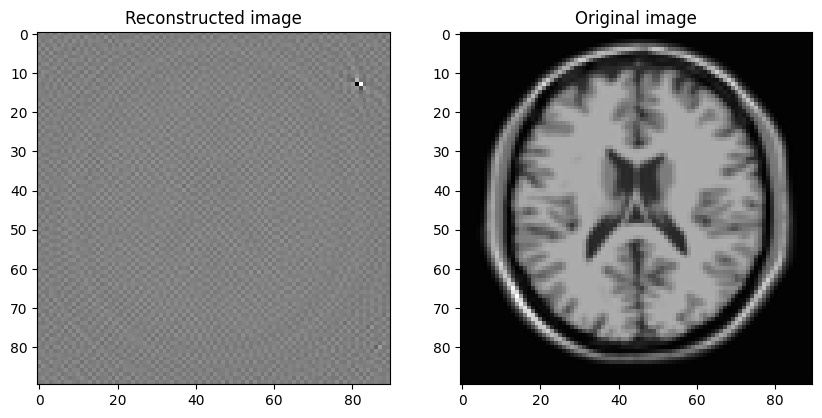

In [38]:
x0 = np.zeros_like(x)
x_mmg = mmmg(x0, n_iter=200)
X_mmg = x_mmg.reshape((90,90),order='F')
plt.figure(figsize=(10,7))
plt.subplot(1,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.subplot(1,2,1)
plt.imshow(X_mmg, cmap='gray')
plt.title("Reconstructed image")
plt.show()

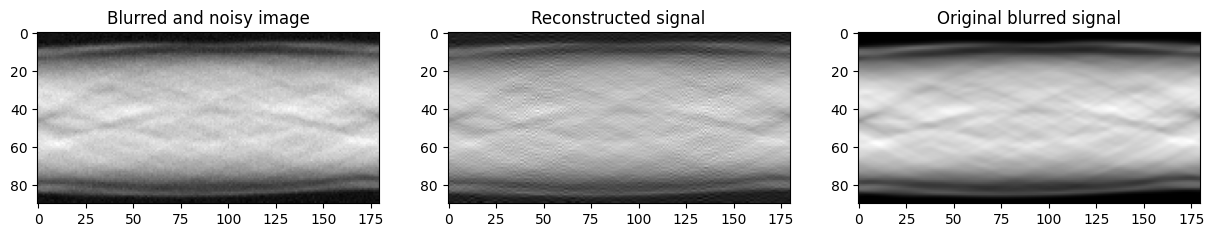

In [ ]:
y_mmg = H @ x_mmg  
Y_mmg = y_mmg.reshape((90,180),order='F')
plt.figure(figsize=(15,7))
plt.subplot(1,3,2)
plt.imshow(Y_mmg, cmap='gray')
plt.title("Reconstructed signal")
plt.subplot(1,3,1)
plt.imshow(Y, cmap='gray')
plt.title("Blurred and noisy image")
plt.subplot(1,3,3)
y2 = H @ x
Y2 = y2.reshape((90,180),order='F')
plt.imshow(Y2, cmap='gray')
plt.title("Original blurred signal")
plt.show()


In [ ]:
def A_block(j,nj):
    # Majoration of the Hessian of f with the second derivative of the regularizer
    d = 1/(delta**2) *np.ones(G.shape[0])
    A = H.T @ H + lamb *G.T @ diags(d,offsets=0).tocsc() @ G #A symétrique définie positive
    Aj = A[j:j+nj,j:j+nj]
    curv_Aj = LinearOperator(shape=(nj,nj), matvec=lambda v: Aj @ v)
    return curv_Aj

def A_block(j,nj, xn):
    # Majoration of the Hessian of f with the second derivative of the regularizer
    d = psi_2nd(G @ xn)
    A = H.T @ H + lamb *G.T @ diags(d,offsets=0).tocsc() @ G #A symétrique définie positive
    Aj = A[j:j+nj,j:j+nj]
    curv_Aj = LinearOperator(shape=(nj,nj), matvec=lambda v: Aj @ v)
    return curv_Aj 

def mm_block(x0,k=1,theta=1, n_iter=100):
    xn = x0.copy()
    xn1 = xn.copy()
    j = 0
    nj = G.shape[1] // k
    for n in range(n_iter):
        b = grad_f(xn)[j:j+nj]
        Aj = A_block(j,nj,xn)
        temp, exit_code = bicg(LinearOperator(shape=(nj,nj), matvec=lambda v: Aj @ v), b, x0=xn[j:j+nj], rtol=1e-6, maxiter=1000)
        xn1[j:j+nj] = xn[j:j+nj] -theta * temp
        resid = np.linalg.norm(xn1 - xn)
        if resid < 1e-6:
            xn = xn1
            print(f"MM Block Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
        j = (j + 1) % k
    return xn

In [ ]:
plt.figure(figsize=(10,7))
grid_k = [1,2,3,5,6,9]
for i,k in enumerate(grid_k):
    x0 = np.zeros_like(x)
    x_est = mm_block(x0, k=k, n_iter=100)
    X_est = x_est.reshape((90,90),order='F')
    plt.subplot(2,3,i+1)
    plt.imshow(X_est, cmap='gray')
    plt.title(f"Reconstructed image\n k={k}, iter=100")
    
plt.subplot(2,3,6)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.show()

In [24]:
A_block(0,10,x)

<10x10 _CustomLinearOperator with dtype=float64>

### 3.5
$$ \forall x \in \mathbf(R)^N, \forall z \in \mathbf(R)^N 
S_i = z^T(B(x) - A(x))z = \sum_{k=1}^{N} \sum_{l=1}^{N} ( z_k z_l ) (b^{(k)}(x) - \sum_{m=1}^{M} H_{mk}H_{ml} - \lambda \sum_{n=1}^{2N} G_{nk} G_{nl} \psi''(Gx^{(k)))
= b^{(i)}(x) - \sum_{k=1}^M H_ki² - \lambda \sum_{k=1}^{2N} G_ki² \psi''(Gx^{k})
S_i \ueq \lambda \sum_{k=1}^{2N} |G_ki| ((\sum{l=1}^{N} |G_lk| \frac{\psi'(Gx^k)}{Gx^k}) - |G_ki| \psi''(Gx^{k}))$$
Comme $\psi''(u) \leq \psi'(u) \forall u \in \mathbf{R}$ alors on a bien $S_i \ueq 0 \forall i \in [1,N]$ donc B(x)-A(x) est bien semi-définie positive.

xiAxi = sum xi ei A sum xj ej = sum sum xi xj ei A ej = sum xi² eiAej + sum sum 
x 1 -1 A

  marche pas calcul brut
